In [36]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad
import os

In [37]:
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
print(os.getcwd())

from perplexity_labelling import compute_p1, compute_p2, compute_p3
from utils import (
    # VISUALIZATION
    rolling_kde_heatmap_with_turns,
    display_turns_colored_by_kde,
    compute_graph_perplexity,
    correlation_heatmap,
    # HELPERS
    compute_dominance_per_spk,
    expand_multiple_ppl_by_token,
    remove_match_prefix_ppl,
    assign_words_to_bins,
    compute_significance,
    display_colored_sentences
)

/u/sebono/conversational_dominance/information_exchange_labelling


In [38]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

#model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"
model_id="gpt2-large"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    #model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
if "Llama" in model_id:
    #model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



### Analysis

In [44]:
import pandas as pd
import re
import numpy as np

noxi_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/Noxi/conversations.csv")
noxi_df.head()

,file_name,file_content
0,S001,"<SPK2> Bonjour. <SPK1> Bonjour, tu m'entends? ..."
1,S002,"<SPK1> Salut, salut ! <SPK1> Salut ! <SPK2> Sa..."
2,S003,<SPK1> Salut ! <SPK2> Salut. <SPK1> Tu m'enten...
3,S006,"<SPK1> Oh putain, c'est parti ! <SPK1> Ok, alo..."
4,S007,<SPK2> Salut ! <SPK2> Salut ! <SPK2> On peut c...


In [115]:
file_name = "S006"
dialog = noxi_df[noxi_df['file_name']==file_name]["file_content"][3]

In [116]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
assert len(matches) == len(dialog_lines)

In [117]:
all_data = pd.DataFrame({})
for p_name in ['p1','p2','p3']:
    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/noxi_{p_name}_{model_id}/dominance_scores_{file_name}.pkl'
    with open(file_name_sample, 'rb') as f:
        all_data[f"{p_name}"] = pickle.load(f)[file_name]

In [118]:
all_data.bfill(inplace=True)

filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

all_data_filtered = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3 })

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


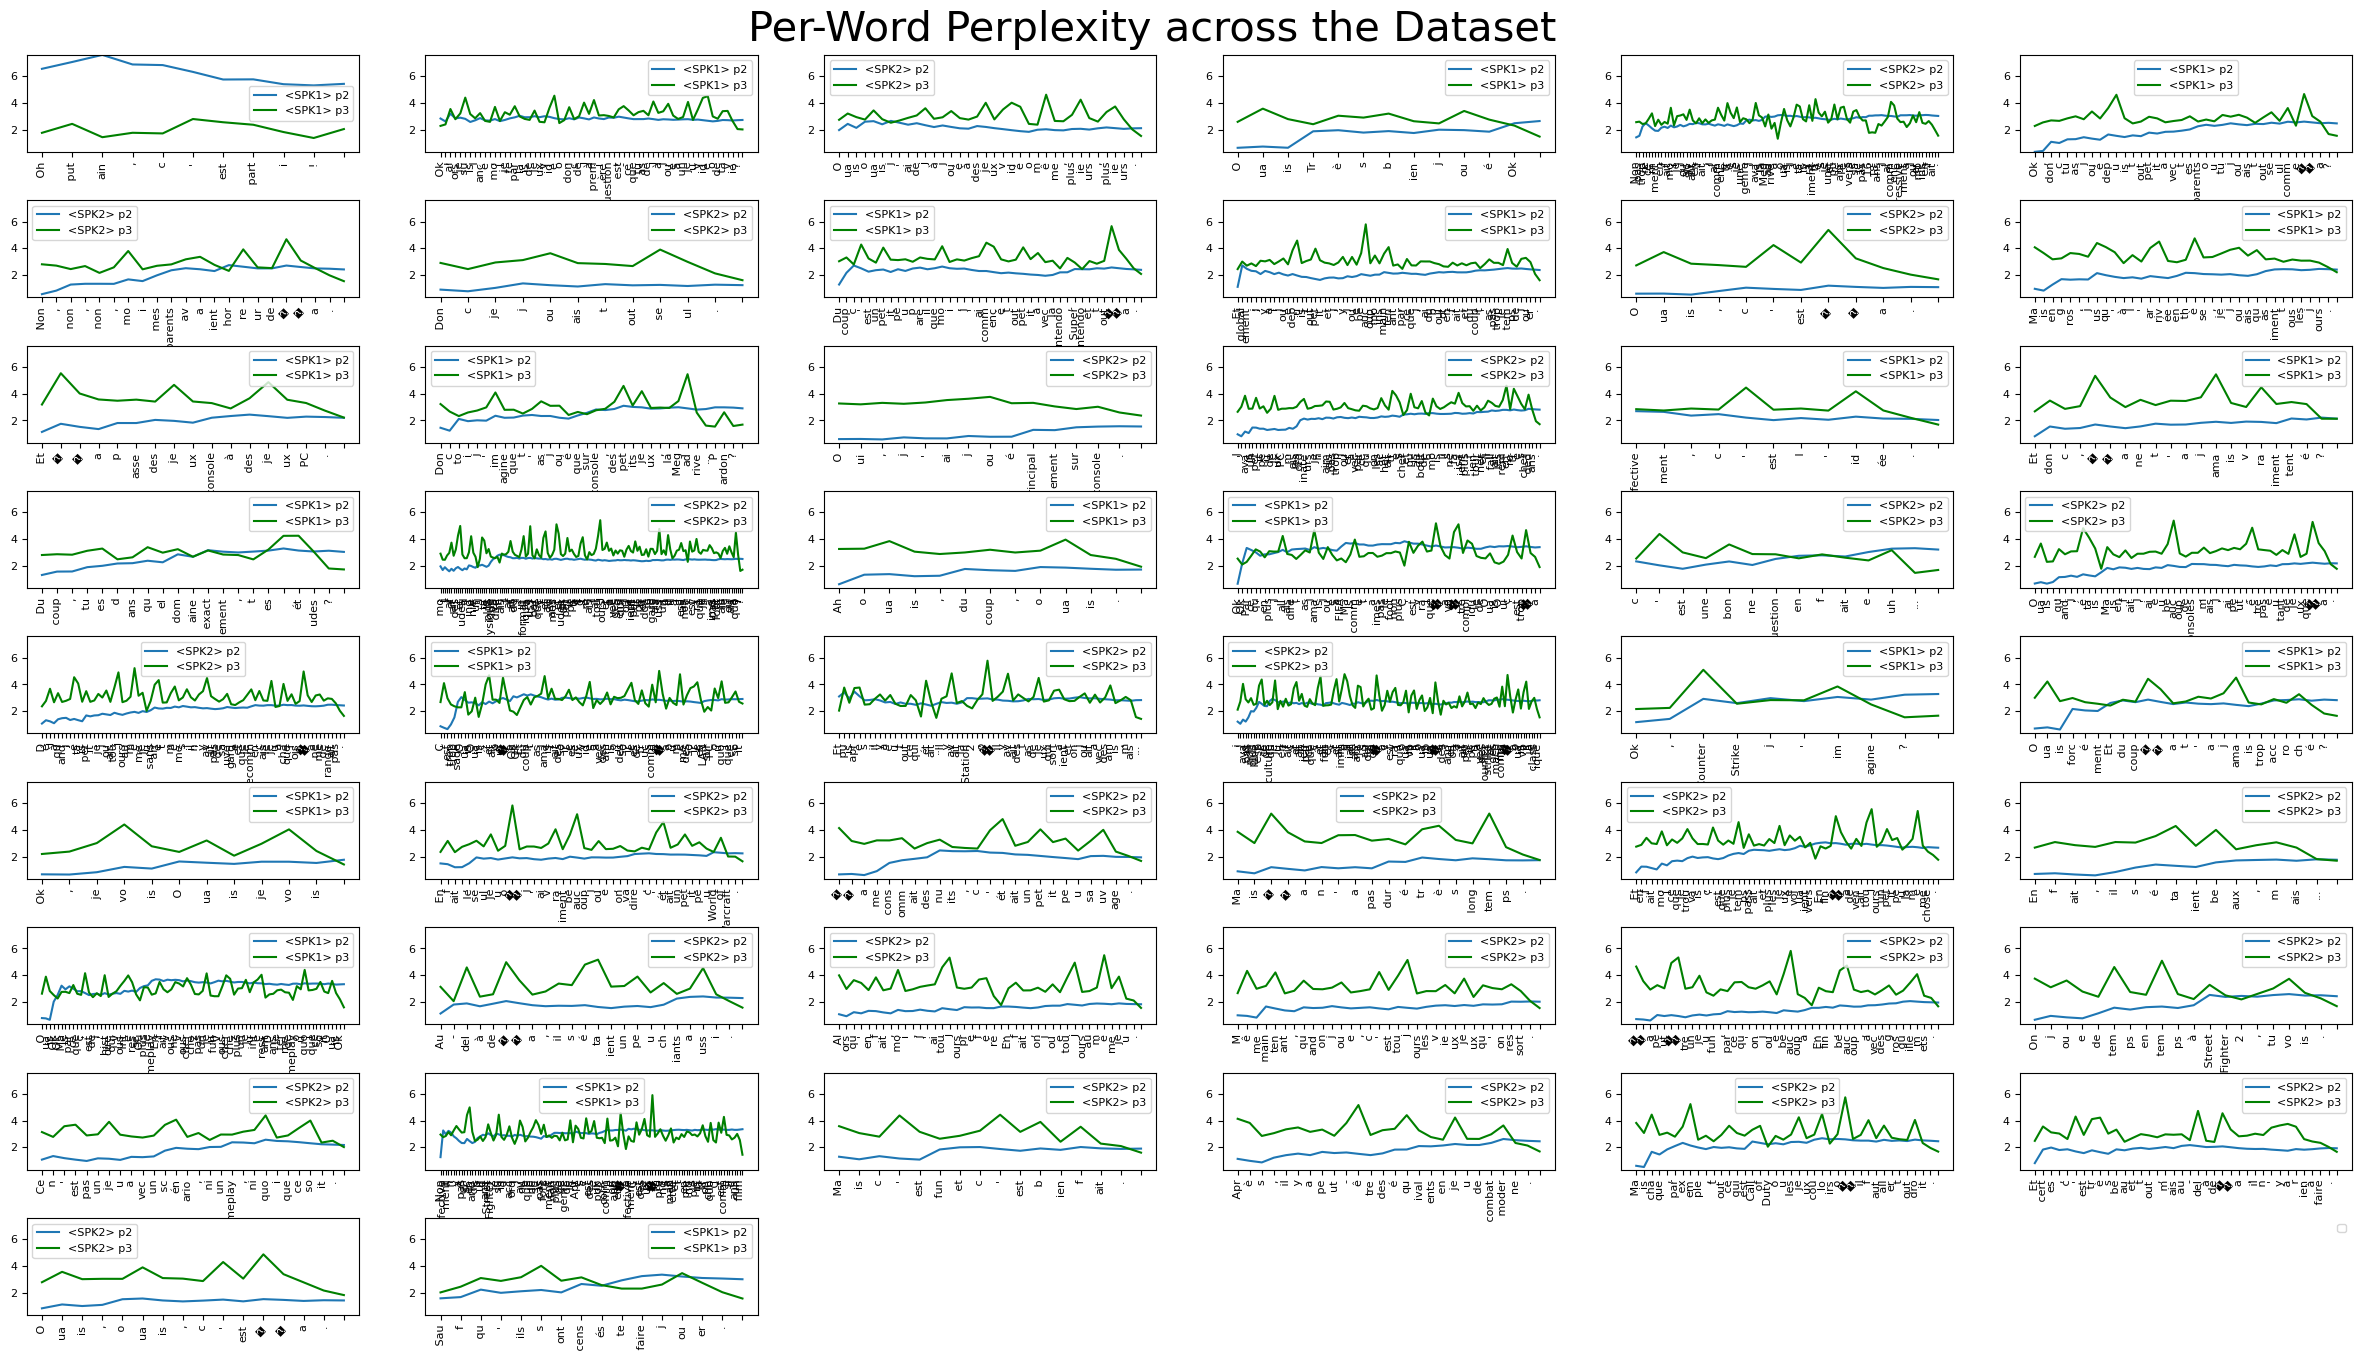

In [119]:
last=50
end = np.cumsum([len(l) for l in filtered_tokens_p1[:last]])[-1]
compute_graph_perplexity(tokenizer, filtered_tokens_p2[:last], filtered_ppl_p2[:end], filtered_ppl_p3[:end], filtered_matches_p2[:last], {"p1":"p2","p2":"p3"}, answers=None)

In [120]:
ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

In [121]:
np.mean(ppls_p1_spk["<SPK1>"]), np.mean(ppls_p2_spk["<SPK1>"]), np.mean(ppls_p3_spk["<SPK1>"])

(2.9779090205723695, 2.437360057064982, 3.074906869745132)

In [122]:
np.mean(ppls_p1_spk["<SPK2>"]), np.mean(ppls_p2_spk["<SPK2>"]), np.mean(ppls_p3_spk["<SPK2>"])

(2.68720913034745, 2.1142577905654907, 3.0577153270509507)

In [123]:
np.mean(ppls_p1_spk['<SPK1>']) > np.mean(ppls_p1_spk['<SPK2>']), np.mean(ppls_p2_spk['<SPK1>']) > np.mean(ppls_p2_spk['<SPK2>']), np.mean(ppls_p3_spk['<SPK1>']) < np.mean(ppls_p3_spk['<SPK2>'])

(True, True, False)

In [58]:
rows, nested = compute_significance(ppls_p2_spk, ['<SPK1>', '<SPK2>'], adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,4052,2515,2.114294e-01,3.235110e-61,3.235110e-61
1,Mann-Whitney U,<SPK1>,<SPK2>,4052,2515,6.392672e+06,1.387501e-67,1.387501e-67
2,T-test,<SPK1>,<SPK2>,4052,2515,1.574446e+01,1.397233e-54,1.397233e-54


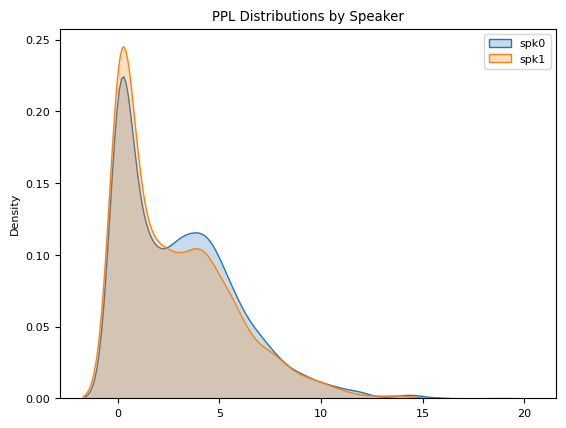

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p1_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p1_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

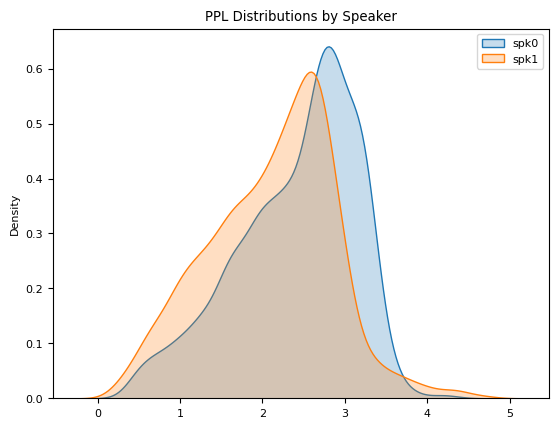

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p2_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p2_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

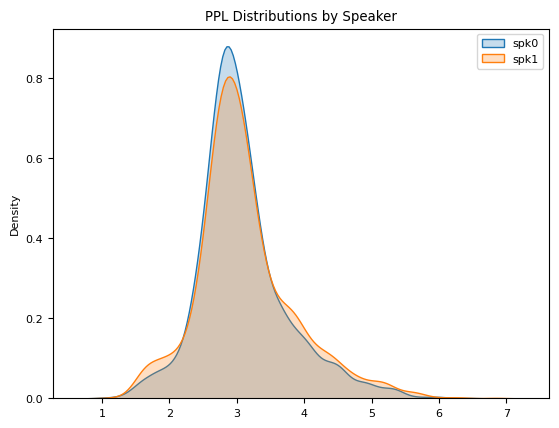

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p3_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p3_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [62]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered)

### Per-turn Analysis

In [125]:
per_turn_ppl = pd.DataFrame({"tokens": filtered_tokens_p1})

In [126]:
from itertools import count

# Start from offset
start_index = 0
counter = count(start=start_index)

# Function to assign token indices
def assign_indices(token_list):
    return [next(counter) for _ in token_list]

per_turn_ppl["ppl"] = per_turn_ppl["tokens"].apply(assign_indices)

In [127]:
per_turn_ppl["ppl"].iloc[-1][-1], len(filtered_ppl_p3)

(11940, 11941)

In [128]:
np.mean(filtered_ppl_p3[0:8])

2.104680433869362

In [129]:
per_turn_ppl["speaker"] = filtered_matches_p1

In [130]:
per_turn_ppl["p1"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p1)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p2"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p2)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p3"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p3)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)

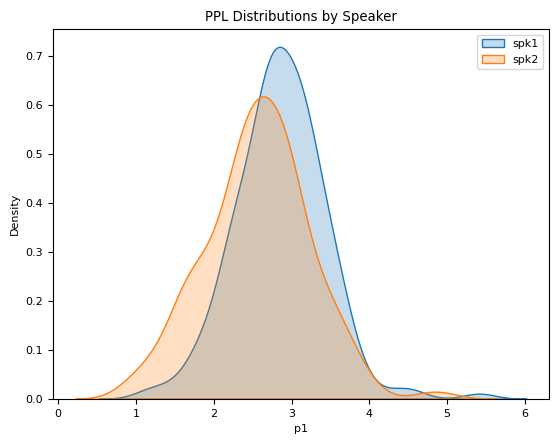

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

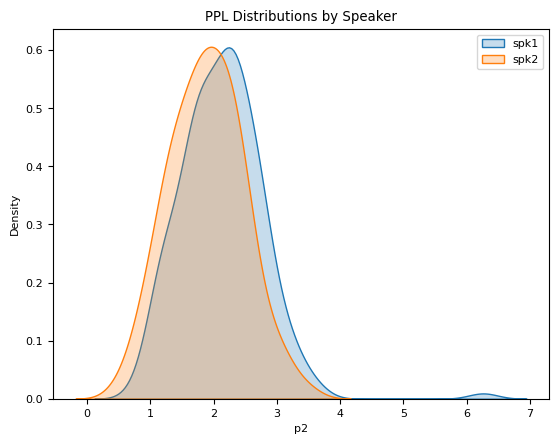

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

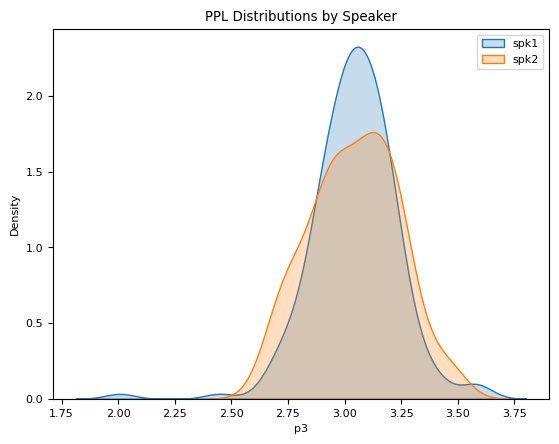

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [134]:
ppls_p1_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p1']})
ppls_p2_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p2']})
ppls_p3_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p3']})

In [135]:
np.mean(ppls_p1_spk["<SPK1>"]), np.mean(ppls_p2_spk["<SPK1>"]), np.mean(ppls_p3_spk["<SPK1>"])

(2.8521905671621735, 2.1280205771554144, 3.0434431731995595)

In [136]:
np.mean(ppls_p1_spk["<SPK2>"]), np.mean(ppls_p2_spk["<SPK2>"]), np.mean(ppls_p3_spk["<SPK2>"])

(2.565219631737486, 1.8835012392288977, 3.0412544650553297)

In [75]:
rows, nested = compute_significance(ppls_p1_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,99,91,0.222444,0.014707,0.014707
1,Mann-Whitney U,<SPK1>,<SPK2>,99,91,5746.000000,0.001048,0.001048
2,T-test,<SPK1>,<SPK2>,99,91,3.337825,0.001044,0.001044


In [76]:
rows, nested = compute_significance(ppls_p2_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df.head()

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,99,91,0.308469,0.000166,0.000166
1,Mann-Whitney U,<SPK1>,<SPK2>,99,91,6141.000000,0.000016,0.000016
2,T-test,<SPK1>,<SPK2>,99,91,4.244095,0.000035,0.000035


In [77]:
rows, nested = compute_significance(ppls_p3_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,99,91,0.097014,0.712734,0.712734
1,Mann-Whitney U,<SPK1>,<SPK2>,99,91,4260.000000,0.519345,0.519345
2,T-test,<SPK1>,<SPK2>,99,91,-0.785715,0.433086,0.433086


In [78]:
per_turn_ppl["dialog"] = per_turn_ppl["tokens"].map(lambda x: " ".join([tokenizer.decode(token, skip_special_tokens=True) for token in x]))

In [83]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,per_turn_ppl)